## PART 2: NLP WORKFLOW

Selecting a reasonably sized corpora to pre-process and analyze using the techniques from lecture. The pre-processing includes cleaning, tokenizing, and normalization. The exploratory analysis includes basic information, description, and visualization.

### Import/Download required NLTK data

In [54]:
# I needed to download some additional stuff since running the book import statement alone was causing errors
# Just so we do not have to download again I will do a try catch block to see if texts are already available

try:
    from nltk.book import *
    from nltk import FreqDist
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer, PorterStemmer
    from nltk import download
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import re
    download("punkt_tab")
    print("All imports are successful")
except LookupError as e:
    print(f"Import failed: {e}")
    print("Downloading is required for corpora. Starting downloading...")
    import nltk
    nltk.download('gutenberg')
    nltk.download('genesis')
    nltk.download('inaugural')
    nltk.download('nps_chat')
    nltk.download('webtext')
    nltk.download('treebank')
    nltk.download('stopwords')
    nltk.download('punkt_tab')  # Updated from 'punkt'
    nltk.download('wordnet')
    from nltk.book import *
    print("NLTK book imported after downloads.")

All imports are successful


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rudra\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Loading/Displaying basic information about my selection

In [55]:
print(f"Corpus: {text7.name}")
print(f"Number of tokens: {len(text7)}")
print(f"Number of types: {len(set(text7))}")
print(f"Number of types (lowercased): {len(set(word.lower() for word in text7))}")
print(f"Number of types (no punctuation): {len(set(word.lower() for word in text7 if word.isalpha()))}")

Corpus: Wall Street Journal
Number of tokens: 100676
Number of types: 12408
Number of types (lowercased): 11387
Number of types (no punctuation): 9109


### Looking at Frequency Distributions

In [56]:
# General frequency distribution including the punctuation
frequency_distribution = FreqDist(word.lower() for word in text7)
print("Top 50 most common words:")
print(frequency_distribution.most_common(50))

# Specifically looking at words
print(f"\nFrequency of the word 'the' is: {frequency_distribution['the']}")
print(f"Frequency of word 'company' is: {frequency_distribution['company']}")
print(f"Frequency of word 'stock' is: {frequency_distribution['stock']}")

Top 50 most common words:
[(',', 4885), ('the', 4764), ('.', 3828), ('of', 2325), ('to', 2182), ('a', 1988), ('in', 1769), ('and', 1556), ('*-1', 1123), ('0', 1099), ('*', 965), ("'s", 865), ('for', 853), ('that', 848), ('*t*-1', 806), ('*u*', 744), ('$', 718), ('``', 702), ("''", 684), ('is', 672), ('said', 628), ('it', 577), ('on', 508), ('%', 446), ('by', 440), ('at', 430), ('as', 415), ('with', 398), ('from', 391), ('million', 383), ('mr.', 375), ('*-2', 372), ('are', 369), ('was', 367), ('be', 356), ('*t*-2', 345), ('its', 343), ('has', 339), ('an', 335), ('new', 328), ('have', 325), ("n't", 325), ('but', 309), ('he', 303), ('or', 294), ('will', 281), ('they', 263), ('company', 260), ('--', 230), ('which', 225)]

Frequency of the word 'the' is: 4764
Frequency of word 'company' is: 260
Frequency of word 'stock' is: 172


In [57]:
# Frequency distribution of title case words (words starting with uppercase letter)
frequency_dist_titlecase = FreqDist(word for word in text7 if word.istitle())
print("Top 10 title case words:")
print(frequency_dist_titlecase.most_common(10))

Top 10 title case words:
[('*T*-1', 806), ('*U*', 744), ('The', 717), ('Mr.', 375), ('*T*-2', 345), ('U.S.', 221), ('In', 197), ('New', 165), ('But', 158), ('Corp.', 117)]


In [58]:
# Frequency distribution for word lengths
frequency_dist_wordlen = FreqDist(len(word) for word in text7)
print(f"Most common word length is of length {frequency_dist_wordlen.max()}")
print("\nTop 5 most common word lengths:")
print(frequency_dist_wordlen.most_common(5))

Most common word length is of length 3

Top 5 most common word lengths:
[(3, 16993), (2, 14856), (1, 14821), (4, 13068), (5, 10573)]


In [59]:
# Long words
word_set = set(text7)
long_words = [word for word in word_set if len(word) > 15]
print(f"There are {len(long_words)} words longer than 15 characters")

There are 120 words longer than 15 characters


### Pre-processing, Cleanup, Tokenizing, and Normalization of Data

In [60]:
# Raw Text
raw_text = ' '.join(text7)

# Cleaning the data
# We are removing punctuation and making it lowercase 
cleaned_data = re.sub(r'[^\w\s]', '', raw_text.lower())

# Tokenizing data
tokens = nltk.word_tokenize(cleaned_data)

# Removing stopwords
stop_words = set(stopwords.words('english'))
data_no_stop = [word for word in tokens if word not in stop_words and word.isalpha()]

# Stemming Porter
porter = PorterStemmer()
stemmed = [porter.stem(word) for word in data_no_stop]

# Lemmatization
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(word) for word in data_no_stop]

print(f"Original tokens: {len(tokens)}")
print(f"After stopword removal: {len(data_no_stop)}")
print(f"Sample stemmed: {stemmed[:10]}")
print(f"Sample lemmatized: {lemmatized[:10]}")

Original tokens: 87610
After stopword removal: 48563
Sample stemmed: ['pierr', 'vinken', 'year', 'old', 'join', 'board', 'nonexecut', 'director', 'nov', 'mr']
Sample lemmatized: ['pierre', 'vinken', 'year', 'old', 'join', 'board', 'nonexecutive', 'director', 'nov', 'mr']


### Visualizing the data

C:\Users\rudra\AppData\Local\Temp\ipykernel_13168\1641192163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_freq, palette='viridis')


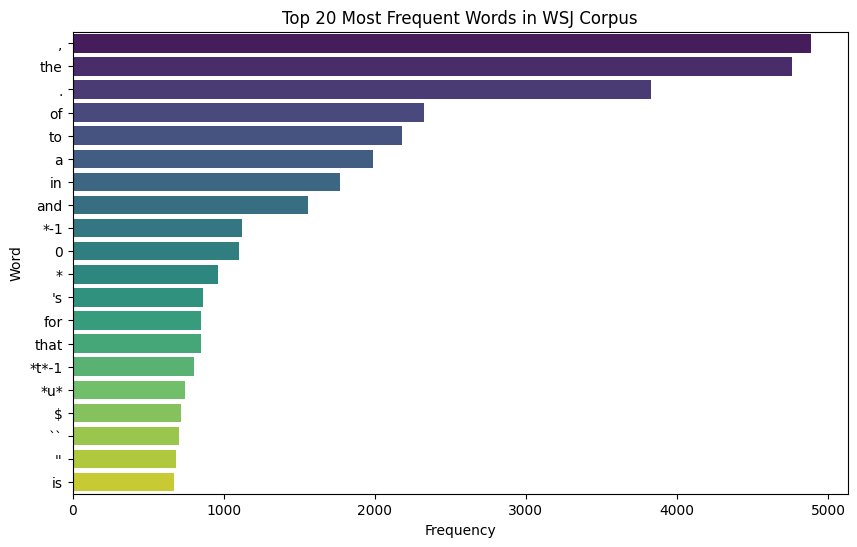

In [61]:
common_words = frequency_distribution.most_common(20)
df_freq = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=df_freq, palette='viridis')
plt.title('Top 20 Most Frequent Words in WSJ Corpus')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

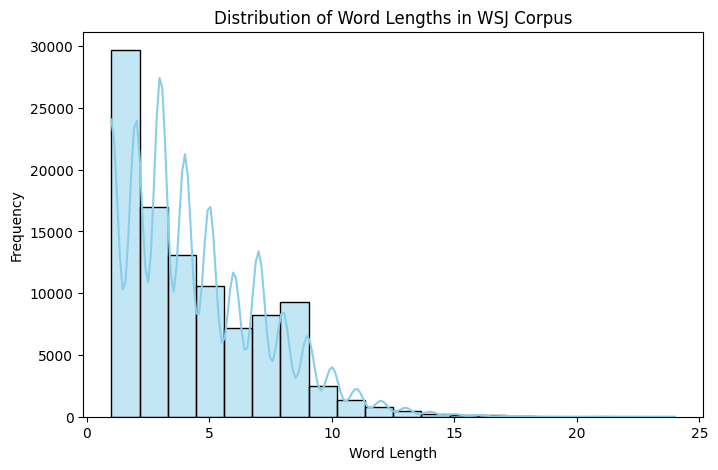

In [62]:
word_lengths = [len(word) for word in text7]
plt.figure(figsize=(8, 5))
sns.histplot(word_lengths, bins=20, kde=True, color='skyblue')
plt.title('Distribution of Word Lengths in WSJ Corpus')
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.show()

C:\Users\rudra\AppData\Local\Temp\ipykernel_13168\944850011.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=df_title, palette='coolwarm')


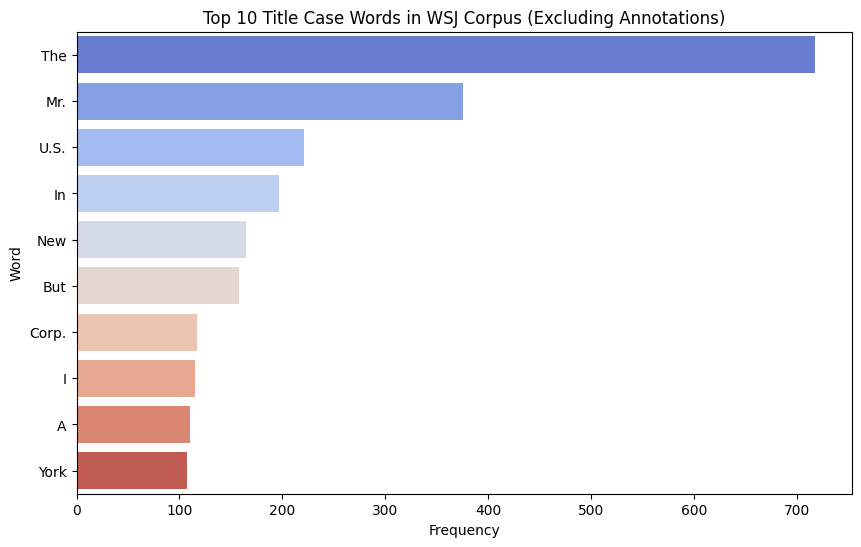

In [63]:
title_freq_filtered = FreqDist(word for word in text7 if word.istitle() and not word.startswith('*'))
title_common = title_freq_filtered.most_common(10)
df_title = pd.DataFrame(title_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=df_title, palette='coolwarm')
plt.title('Top 10 Title Case Words in WSJ Corpus (Excluding Annotations)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

### Summary of this part of the assignment
- **Corpus**: I chose Wall Street Journal (text7)
- **Pre-processing**: I cleaned, tokenized, and normalized (stemmed/lemmatized) the data with stopwords.
- **Analysis**: I noticed that frequent words are dominated by common terms like 'the'. Word lengths peak at 3-4 characters and title case includes proper nouns.
- **Insights**: The corpus reflects financial news with terms like 'company' and 'stock'. Visualizations show skewed distributions.